In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/refs/heads/master/weather.csv"
df = pd.read_csv(url)

df.head()

,Unnamed: 0,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
0,1,EWR,2013,1.0,1.0,0.0,37.04,21.92,53.97,230.0,10.35702,11.918651,0.0,1013.9,10.0
1,2,EWR,2013,1.0,1.0,1.0,37.04,21.92,53.97,230.0,13.80936,15.891535,0.0,1013.0,10.0
2,3,EWR,2013,1.0,1.0,2.0,37.94,21.92,52.09,230.0,12.65858,14.567241,0.0,1012.6,10.0
3,4,EWR,2013,1.0,1.0,3.0,37.94,23.00,54.51,230.0,13.80936,15.891535,0.0,1012.7,10.0
4,5,EWR,2013,1.0,1.0,4.0,37.94,24.08,57.04,240.0,14.96014,17.215830,0.0,1012.8,10.0


In [8]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8719 entries, 0 to 8718
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8719 non-null   int64  
 1   origin      8719 non-null   object 
 2   year        8719 non-null   int64  
 3   month       8718 non-null   float64
 4   day         8718 non-null   float64
 5   hour        8718 non-null   float64
 6   temp        8718 non-null   float64
 7   dewp        8718 non-null   float64
 8   humid       8718 non-null   float64
 9   wind_dir    8486 non-null   float64
 10  wind_speed  8718 non-null   float64
 11  wind_gust   8718 non-null   float64
 12  precip      8719 non-null   float64
 13  pressure    7780 non-null   float64
 14  visib       8719 non-null   float64
dtypes: float64(12), int64(2), object(1)
memory usage: 1021.9+ KB


,0
Unnamed: 0,0
origin,0
year,0
month,1
day,1
hour,1
temp,1
dewp,1
humid,1
wind_dir,233


In [11]:
df.columns

Index(['Unnamed: 0', 'origin', 'year', 'month', 'day', 'hour', 'temp', 'dewp',
       'humid', 'wind_dir', 'wind_speed', 'wind_gust', 'precip', 'pressure',
       'visib'],
      dtype='object')

In [12]:
df = df.drop(columns=['Unnamed: 0'])

In [13]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8719 entries, 0 to 8718
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      8719 non-null   object 
 1   year        8719 non-null   int64  
 2   month       8718 non-null   float64
 3   day         8718 non-null   float64
 4   hour        8718 non-null   float64
 5   temp        8718 non-null   float64
 6   dewp        8718 non-null   float64
 7   humid       8718 non-null   float64
 8   wind_dir    8486 non-null   float64
 9   wind_speed  8718 non-null   float64
 10  wind_gust   8718 non-null   float64
 11  precip      8719 non-null   float64
 12  pressure    7780 non-null   float64
 13  visib       8719 non-null   float64
dtypes: float64(12), int64(1), object(1)
memory usage: 953.8+ KB
None
  origin  year  month  day  hour   temp   dewp  humid  wind_dir  wind_speed  \
0    EWR  2013    1.0  1.0   0.0  37.04  21.92  53.97     230.0    10.35702   
1    EWR 

In [14]:
df['date'] = pd.to_datetime(df[['year','month','day','hour']])
df.head()

,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,date
0,EWR,2013,1.0,1.0,0.0,37.04,21.92,53.97,230.0,10.35702,11.918651,0.0,1013.9,10.0,2013-01-01 00:00:00
1,EWR,2013,1.0,1.0,1.0,37.04,21.92,53.97,230.0,13.80936,15.891535,0.0,1013.0,10.0,2013-01-01 01:00:00
2,EWR,2013,1.0,1.0,2.0,37.94,21.92,52.09,230.0,12.65858,14.567241,0.0,1012.6,10.0,2013-01-01 02:00:00
3,EWR,2013,1.0,1.0,3.0,37.94,23.00,54.51,230.0,13.80936,15.891535,0.0,1012.7,10.0,2013-01-01 03:00:00
4,EWR,2013,1.0,1.0,4.0,37.94,24.08,57.04,240.0,14.96014,17.215830,0.0,1012.8,10.0,2013-01-01 04:00:00


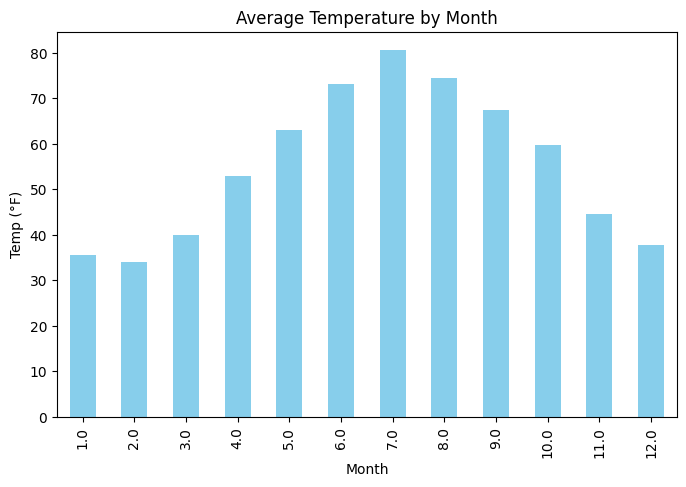

In [17]:
avg_temp_month = df.groupby('month')['temp'].mean()
avg_temp_month.plot(kind='bar', figsize=(8,5), color='skyblue')
plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Temp (°F)")
plt.show()

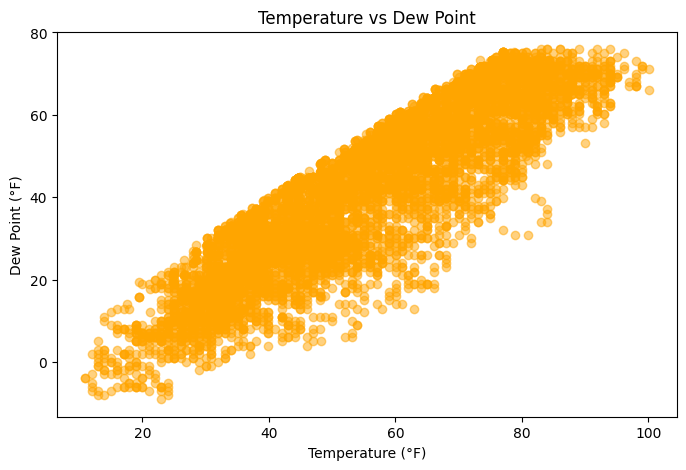

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df['temp'], df['dewp'], alpha=0.5, color='orange')
plt.title("Temperature vs Dew Point")
plt.xlabel("Temperature (°F)")
plt.ylabel("Dew Point (°F)")
plt.show()

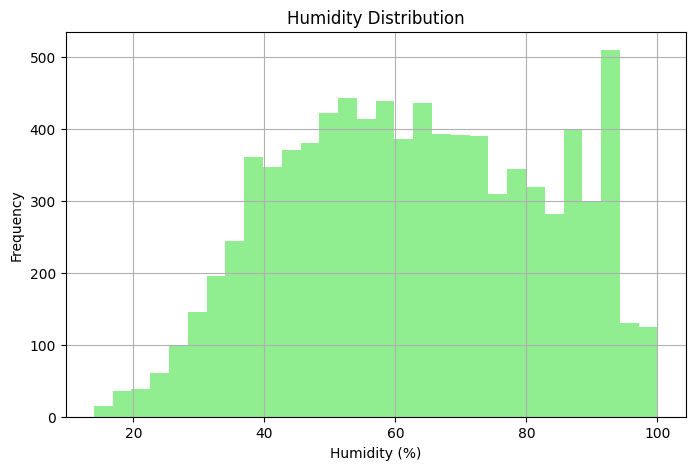

In [19]:
df['humid'].hist(bins=30, figsize=(8,5), color='lightgreen')
plt.title("Humidity Distribution")
plt.xlabel("Humidity (%)")
plt.ylabel("Frequency")
plt.show()

In [24]:
rain_days = (df['precip'] > 0).sum()
no_rain_days = (df['precip'] == 0).sum()
print(f"Days with rain: {rain_days}")
print(f"Days without rain: {no_rain_days}")

Days with rain: 503
Days without rain: 8216


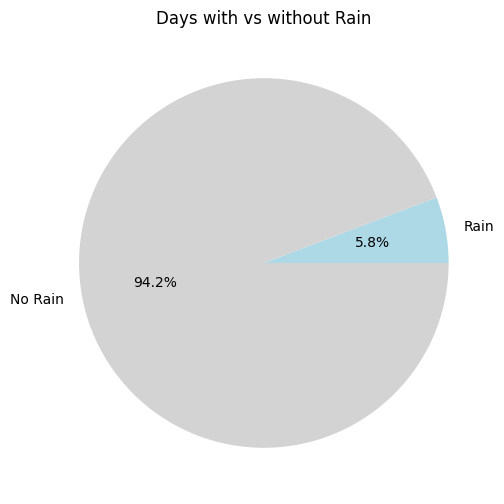

In [25]:
plt.figure(figsize=(6,6))
plt.pie([rain_days, no_rain_days], labels=['Rain', 'No Rain'], autopct='%1.1f%%', colors=['lightblue','lightgray'])
plt.title("Days with vs without Rain")
plt.show()

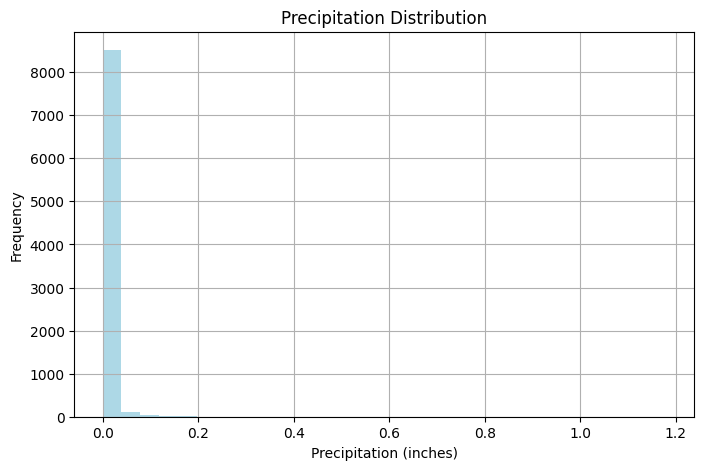

In [21]:
df['precip'].hist(bins=30, figsize=(8,5), color='lightblue')
plt.title("Precipitation Distribution")
plt.xlabel("Precipitation (inches)")
plt.ylabel("Frequency")
plt.show()

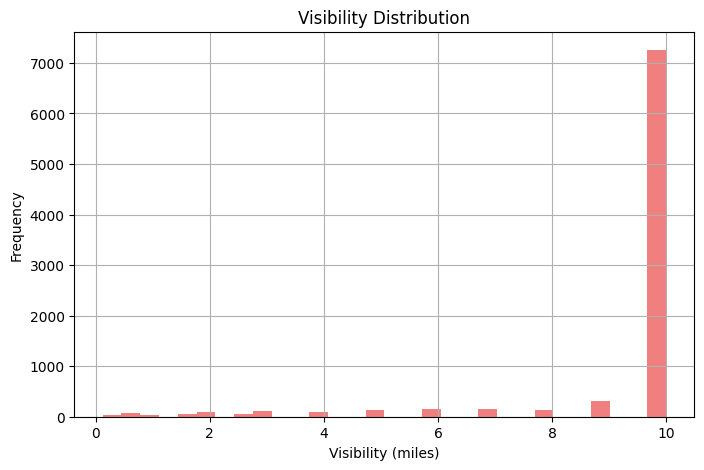

In [22]:
df['visib'].hist(bins=30, figsize=(8,5), color='lightcoral')
plt.title("Visibility Distribution")
plt.xlabel("Visibility (miles)")
plt.ylabel("Frequency")
plt.show()

### Insights

1. **Temperature Trends:**  
   - Average temperatures vary by month, showing clear seasonal patterns.  
   - Temperature correlates with dew point, indicating humidity trends.

2. **Humidity:**  
   - Most humidity readings fall in a moderate range, with occasional high or low extremes.

3. **Precipitation:**  
   - Only a portion of days have measurable precipitation.  
   - Monthly total or frequency of precipitation shows which months are wetter.

4. **Visibility:**  
   - Visibility is generally high, with occasional low-visibility days due to weather events.

**Overall:**  
This project demonstrates data cleaning, aggregation, and visualization of multiple weather metrics. It highlights seasonal trends, rainfall patterns, and general weather conditions using real-world data.